In [4]:
#3열의 csv파일로 Nyquist plot을 그리는 코드입니다.
#csv파일의 첫 번째 열은 주파수, 두 번째 열은 실수부, 세 번째 열은 허수부입니다.

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter

# ====== 1. 폴더 경로 설정 ======
folder_path = r"D:\e4980a\data"

# ====== 2. Nyquist plot에 사용할 주파수 범위 설정 ======
freq_min = 200      # Hz
freq_max = 2_000_000  # Hz (2 MHz)



Plotting: E498x805.csv


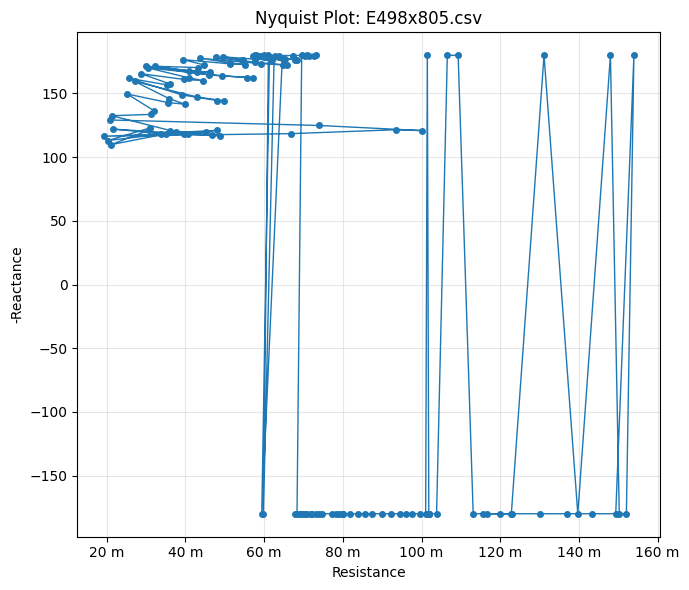

Plotting: E498x806.csv


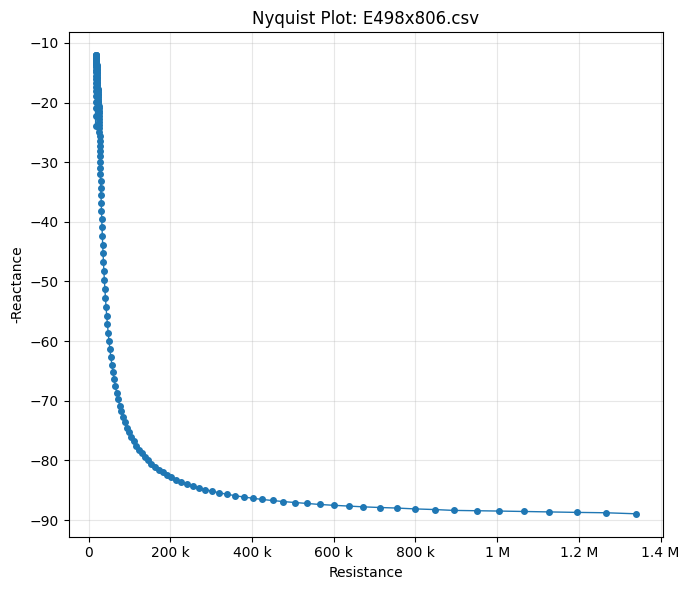

Plotting: E498x807.csv


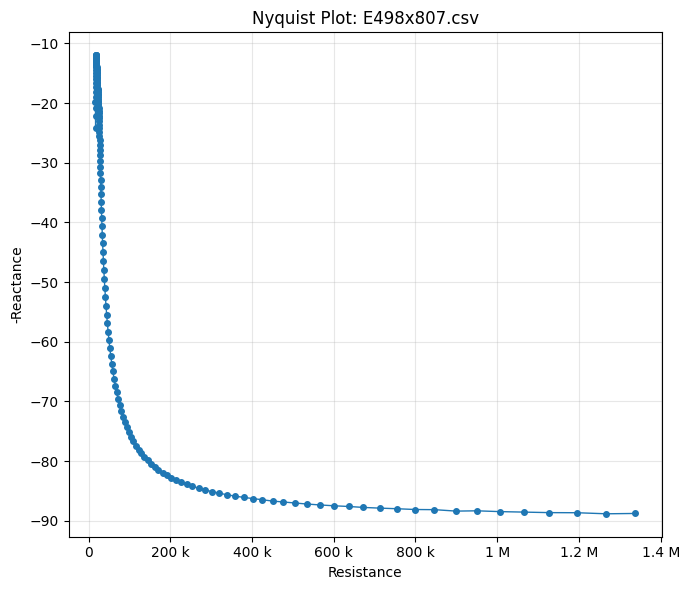

Plotting: E498x808.csv


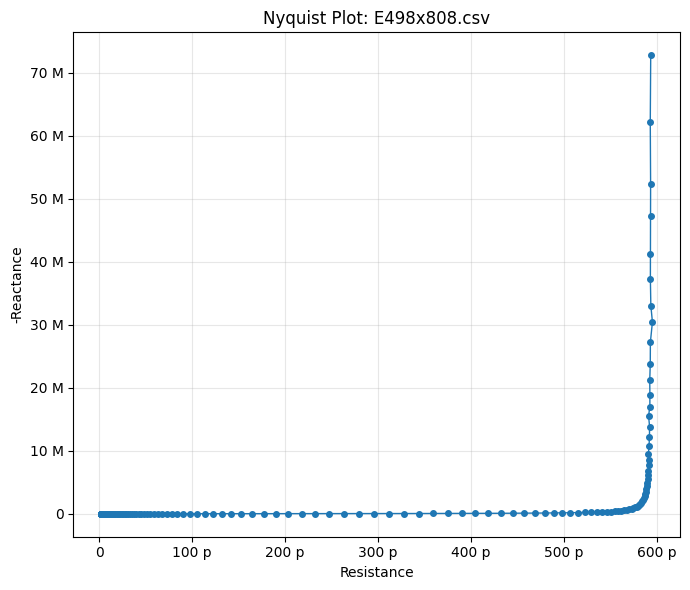

Plotting: E498x809.csv


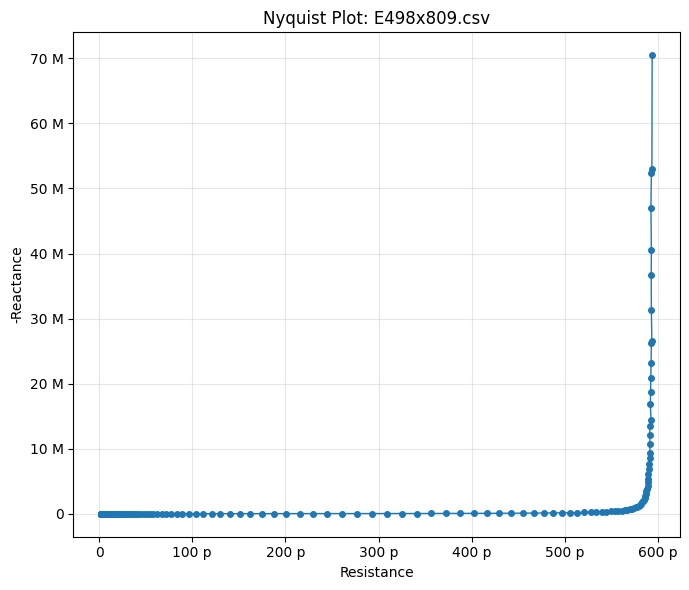

Plotting: E498x810.csv


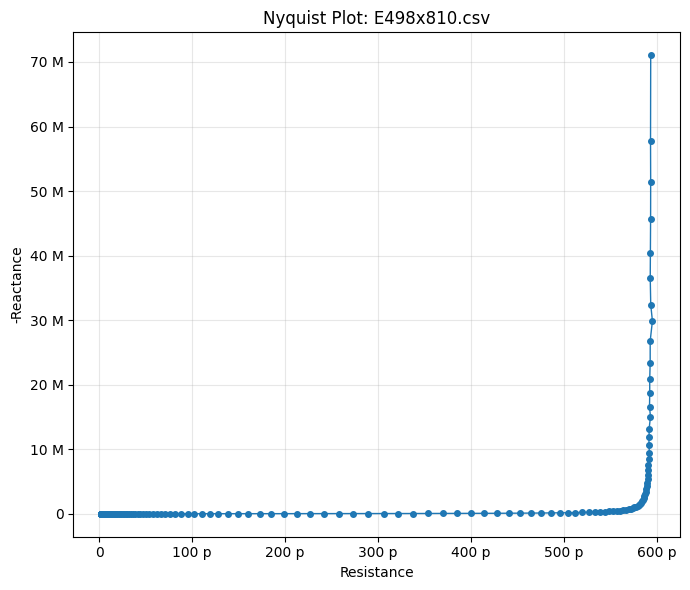

Plotting: E498x811.csv


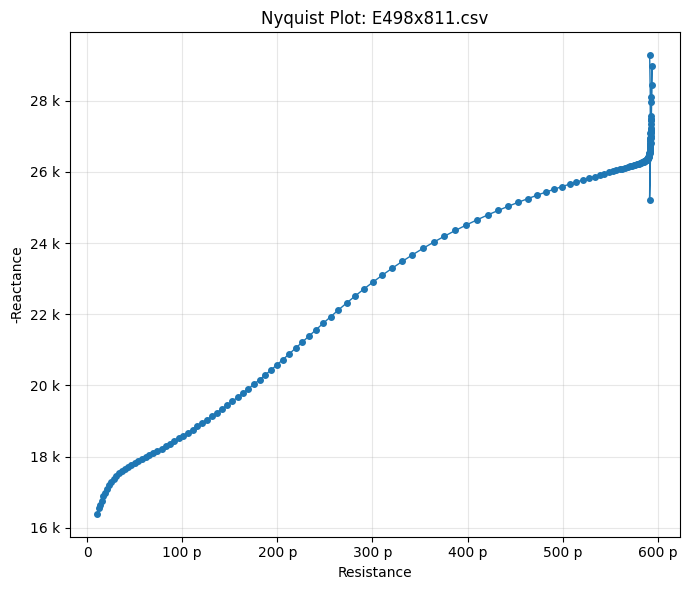

Plotting: E498x812.csv


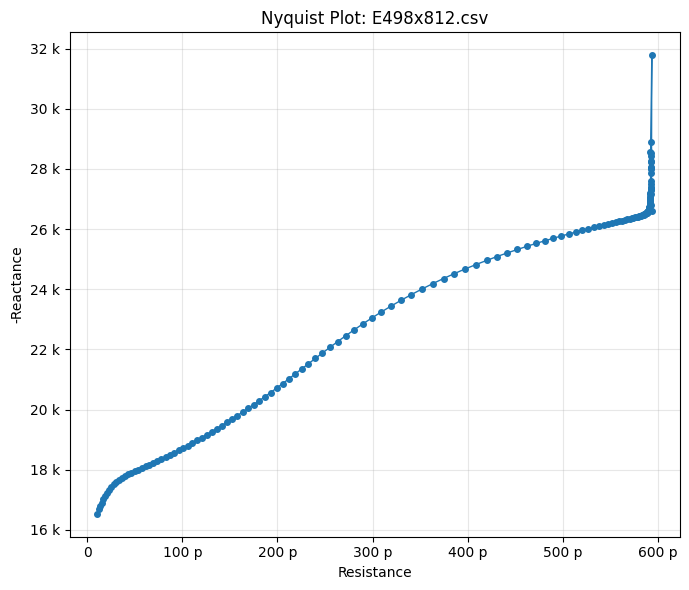

Plotting: E498x813.csv


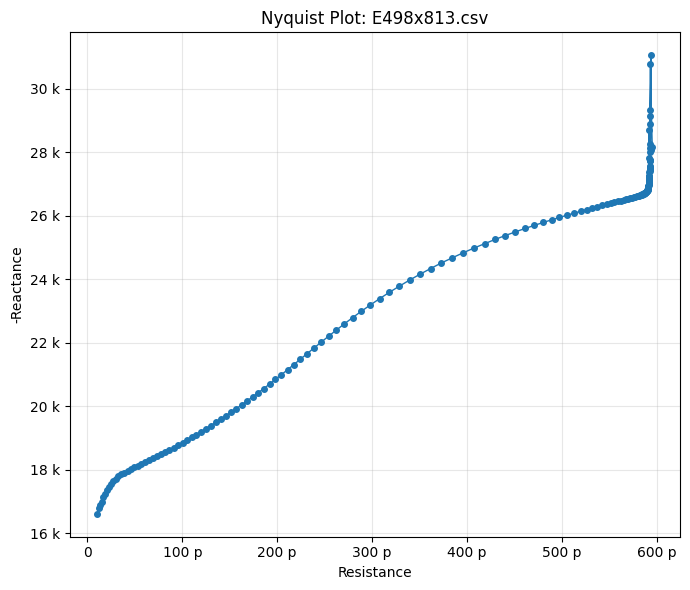

Plotting: E498x814.csv


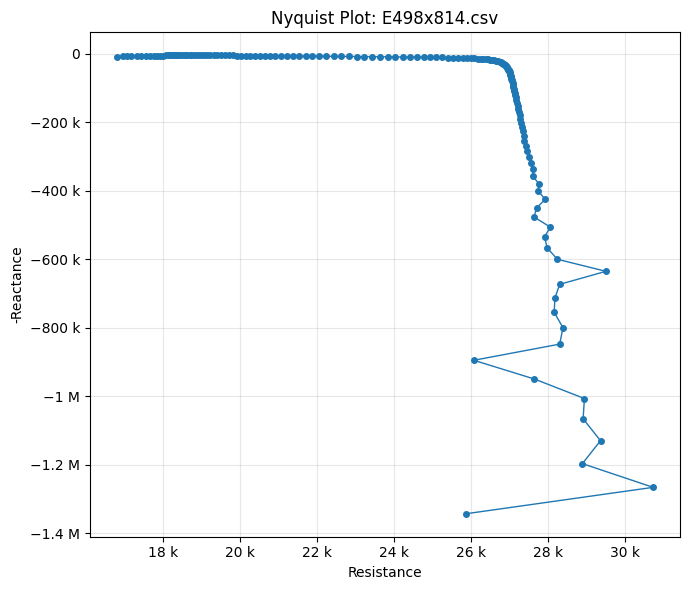

Plotting: E498x815.csv


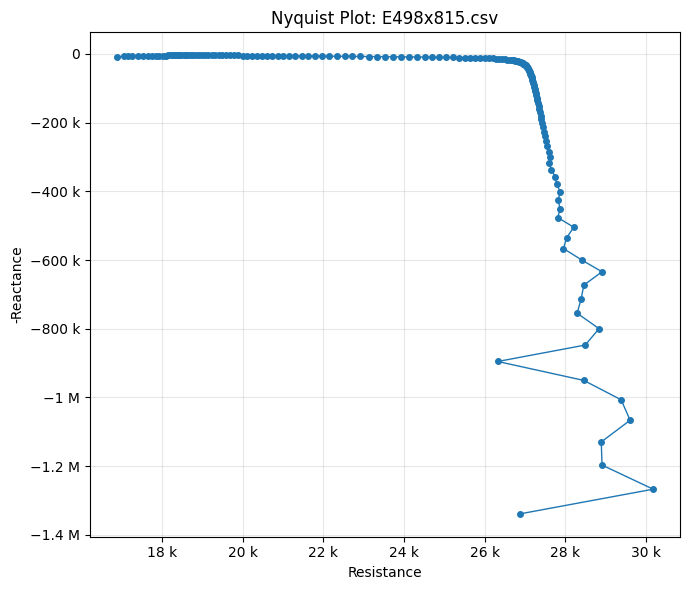

Plotting: E498x816.csv


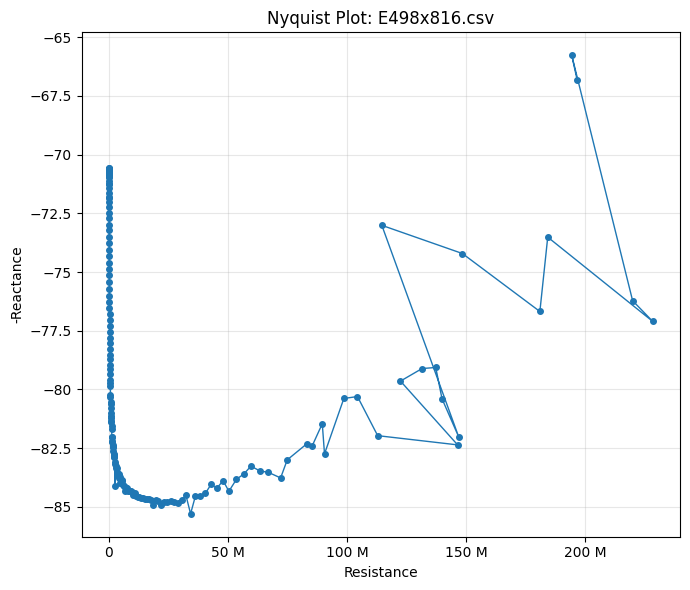

Plotting: E498x817.csv


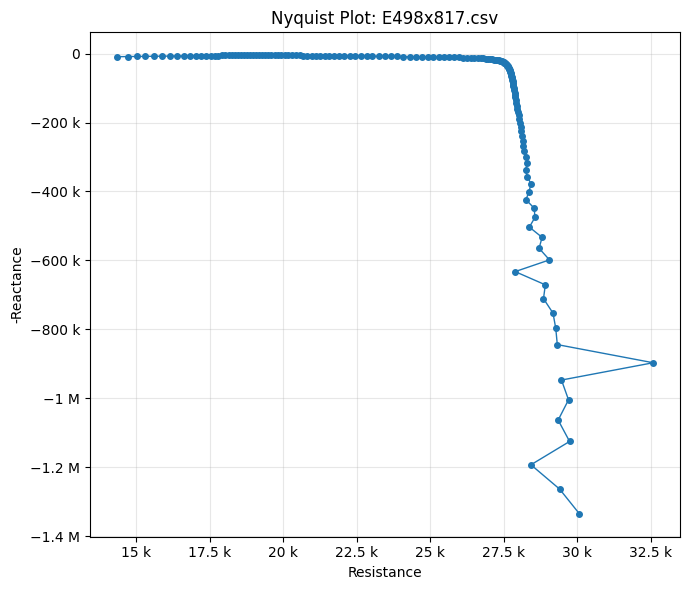

Plotting: E498x818.csv


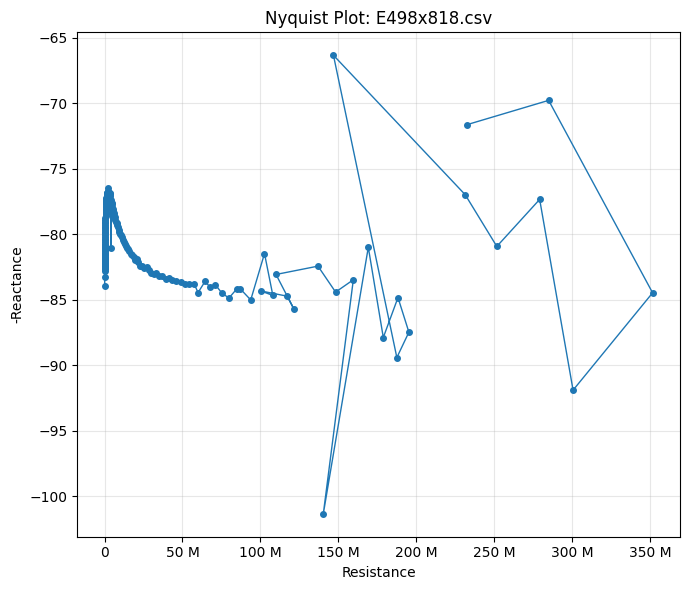

Plotting: E498x819.csv


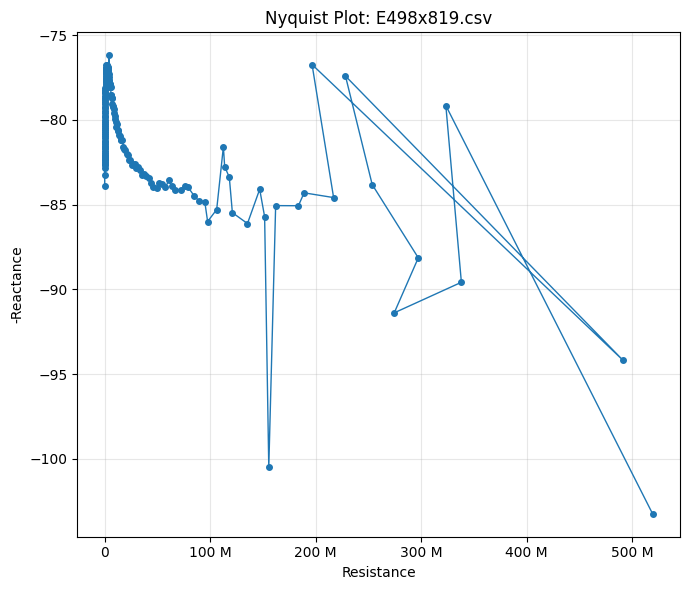

Plotting: E498x820.csv


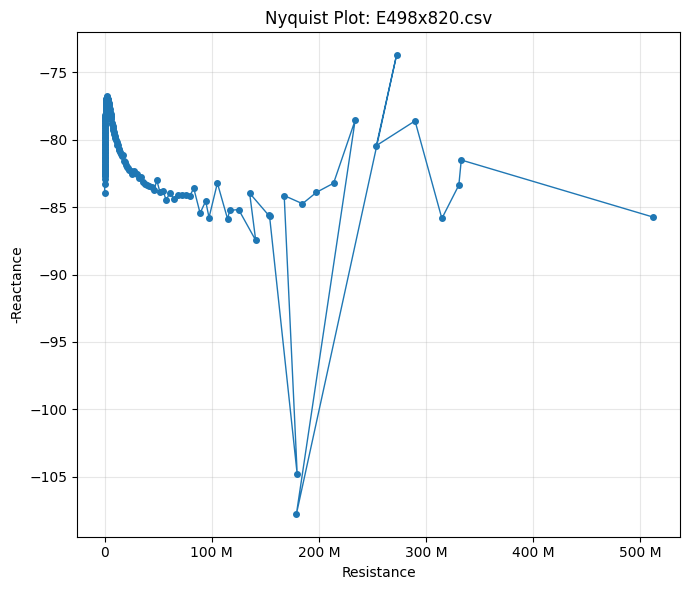

Plotting: E498x821.csv


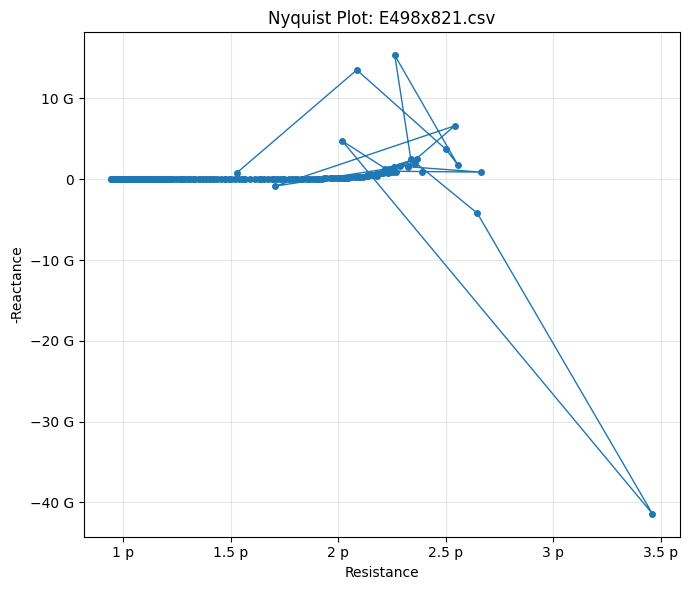

Plotting: E498x822.csv


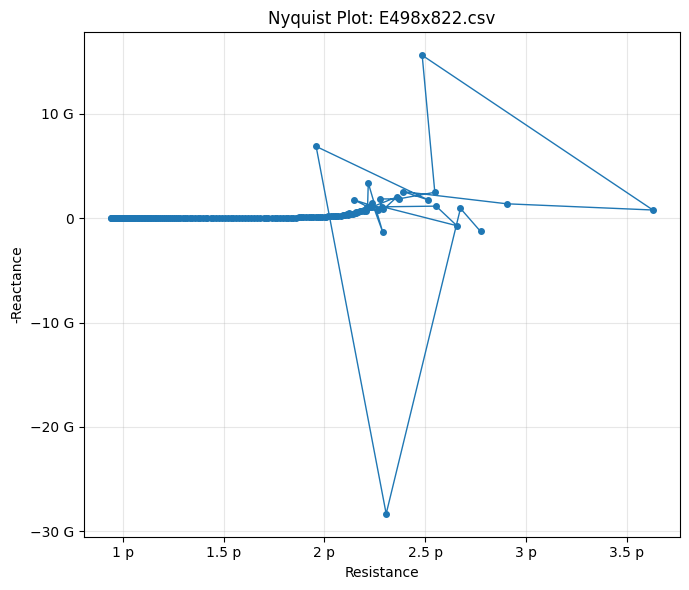

Plotting: E498x823.csv


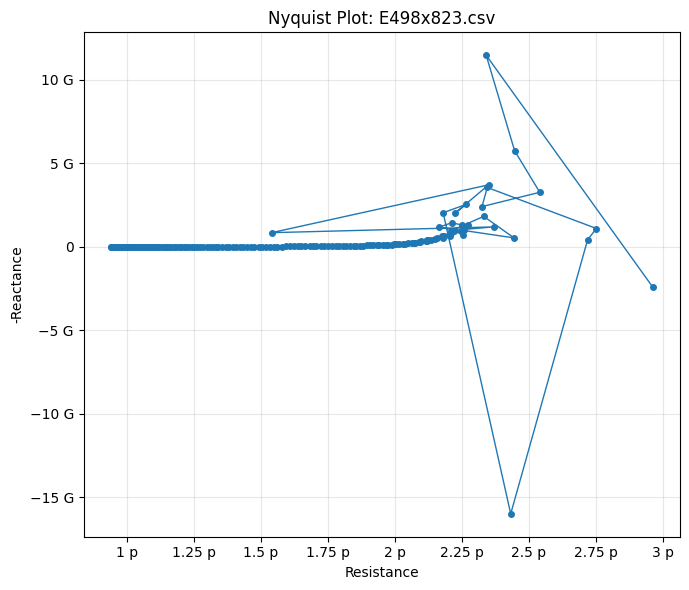

Plotting: E498x824.csv


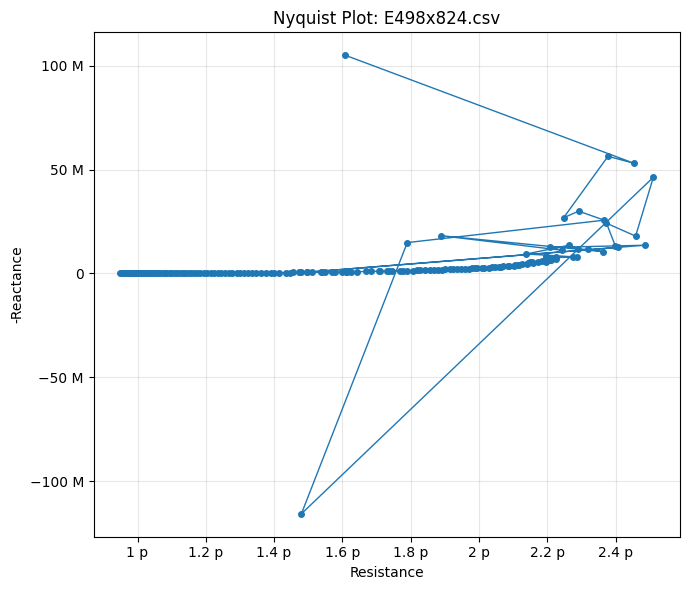

Plotting: E498x825.csv


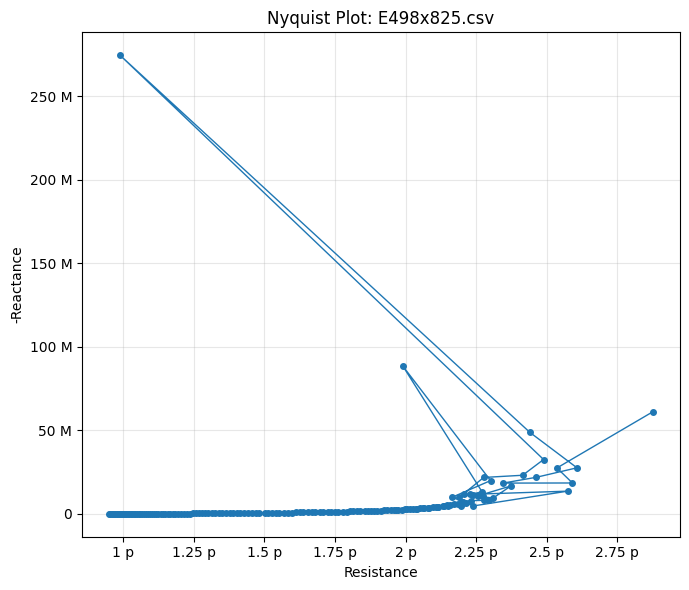

Plotting: E498x826.csv


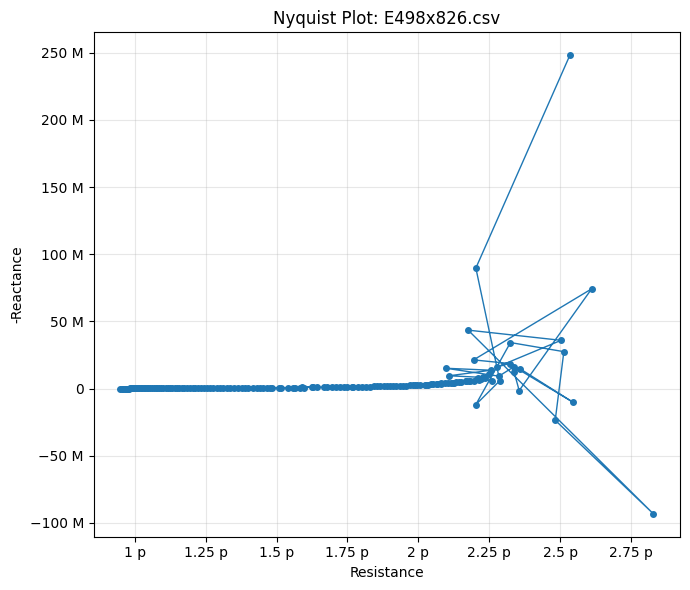

Plotting: E498x827.csv


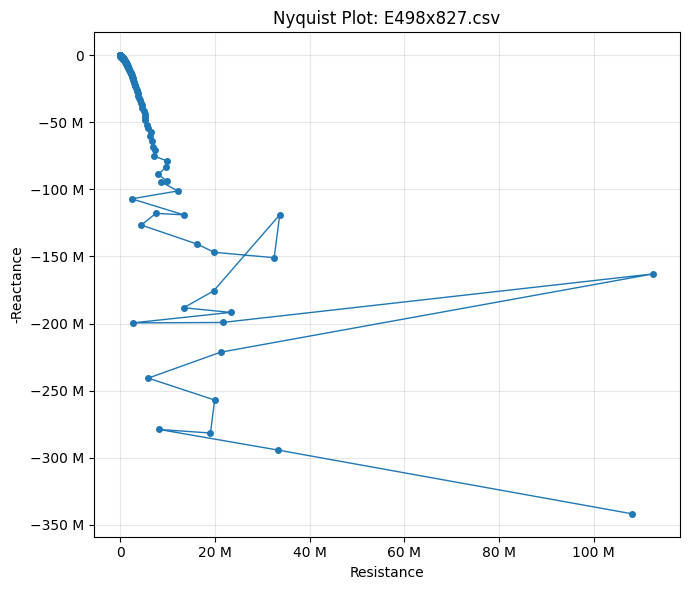

Plotting: E498x828.csv


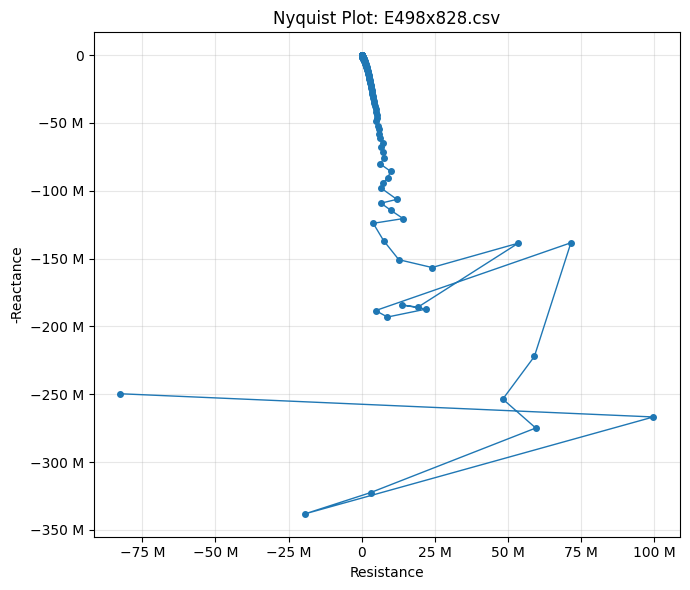

Plotting: E498x829.csv


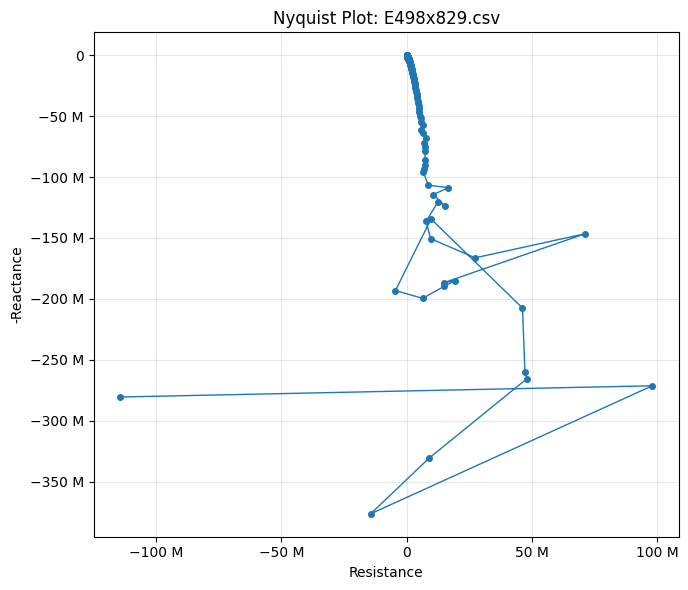

Plotting: E498x830.csv


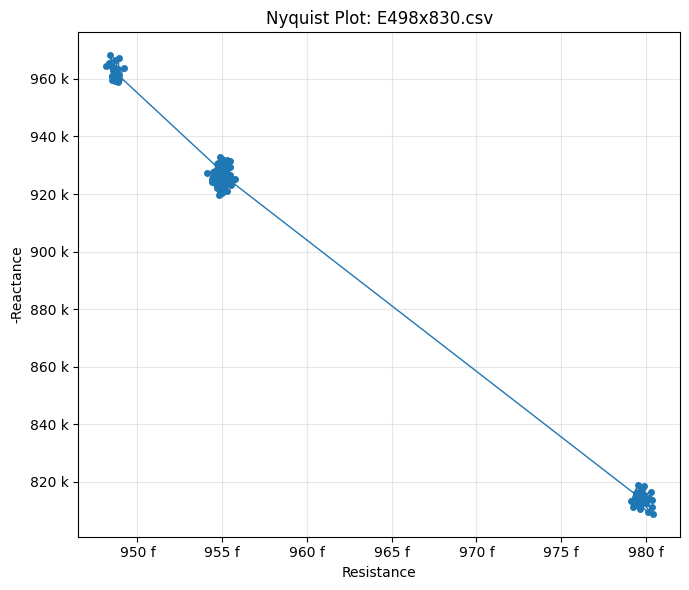

Plotting: E498x831.csv


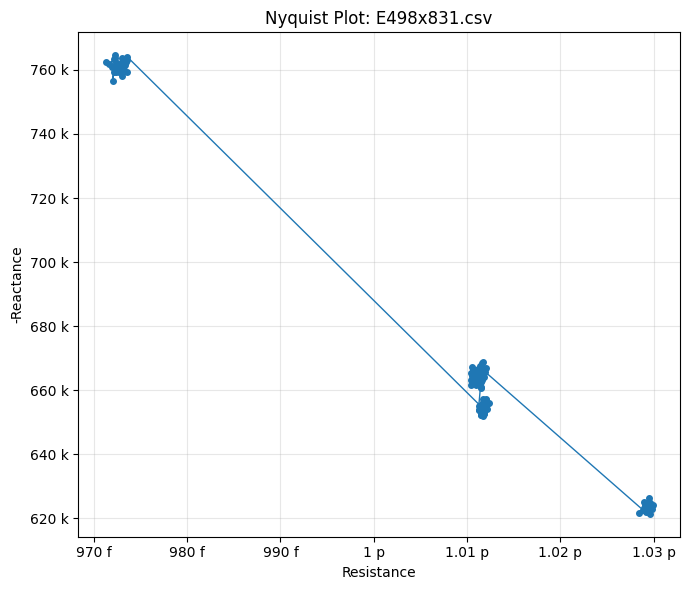

Plotting: E498x832.csv


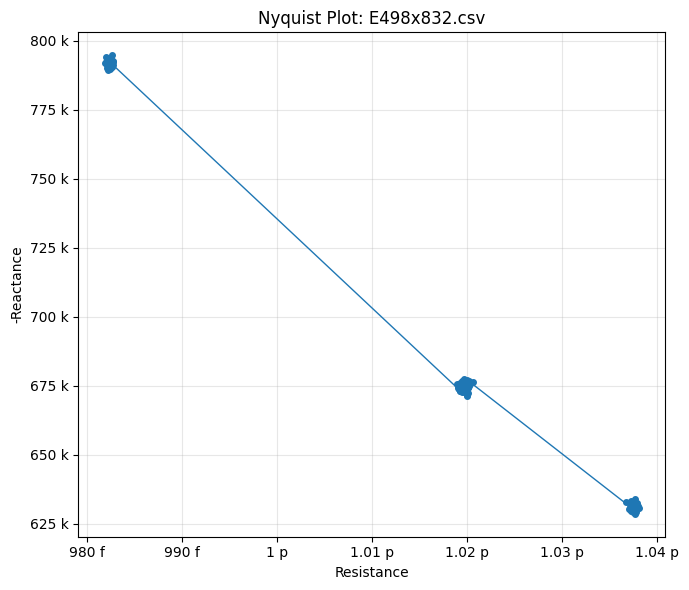

Plotting: E498x833.csv


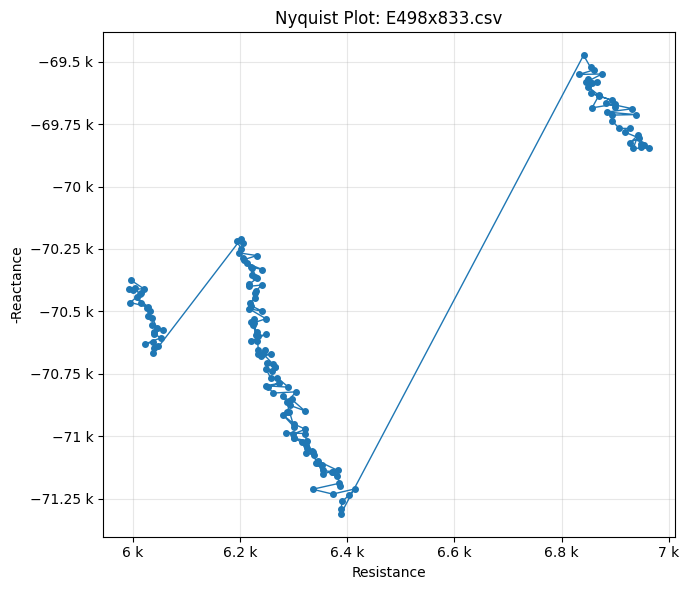

모든 CSV 파일의 Nyquist plot 생성이 완료되었습니다.


In [6]:
csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

if not csv_files:
    print("CSV 파일을 찾지 못했습니다. folder_path를 확인해주세요.")

# ====== 3. 각 CSV 파일의 Nyquist plot 생성 ======
for file in csv_files:
    filename = os.path.basename(file)
    print(f"Plotting: {filename}")

    try:
        df = pd.read_csv(file, header=None)

        if df.shape[1] < 3:
            raise ValueError("CSV 파일은 최소 3개 열(Hz, resistance, reactance)이 필요합니다.")

        freq = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        resistance = pd.to_numeric(df.iloc[:, 1], errors="coerce")
        reactance = pd.to_numeric(df.iloc[:, 2], errors="coerce")

        plot_df = pd.DataFrame({
            "Hz": freq,
            "resistance": resistance,
            "reactance": reactance,
        }).dropna()

        if plot_df.empty:
            raise ValueError("유효한 숫자 데이터가 없습니다.")

        plot_df = plot_df[(plot_df["Hz"] >= freq_min) & (plot_df["Hz"] <= freq_max)]

        if plot_df.empty:
            raise ValueError(f"설정한 주파수 범위({freq_min} Hz ~ {freq_max} Hz)에 해당하는 데이터가 없습니다.")

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(
            plot_df["resistance"],
            plot_df["reactance"],
            marker="o",
            linestyle="-",
            markersize=4,
            linewidth=1,
        )
        ax.set_xlabel("Resistance")
        ax.set_ylabel("-Reactance")
        ax.set_title(f"Nyquist Plot: {filename}")
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(EngFormatter())
        ax.yaxis.set_major_formatter(EngFormatter())
        #ax.axis("equal")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error plotting {filename}: {e}")

print("모든 CSV 파일의 Nyquist plot 생성이 완료되었습니다.")